In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp



In [94]:


phi = 0

b0 = (1+0j) * np.array([0,np.cos(phi),np.sin(phi),0])

w = 1
D = 0
G1 = 2
G2 =  G1



def ham(t,b):
    b1,b2,b3,b4 = b
    der = -1j * np.array([ G1 * b2 + G2 * b3,
                           G1 * b1 + (w/2 - D) * b2 + G2 * b4,
                           G2 * b1 - (w/2 + D) * b3 + G1 * b4,
                           G2 * b2 + G1 * b3 - 2*D * b4])
    return der

In [95]:
t_span = [0,50]

sol = solve_ivp(ham, t_span, b0, method = 'DOP853', max_step = 1e-2)
# sol = solve_ivp(ham, t_span, b0, method = 'RK45', max_step = 1e-3)
print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  3.532e-04 ...  4.999e+01  5.000e+01]
        y: [[ 0.00000000e+00+0.00000000e+00j
             -6.23751748e-08-7.06400131e-04j ...
             -6.66894037e-03-2.24634510e-01j
             -7.37233666e-03-2.35469437e-01j]
            [ 1.00000000e+00+0.00000000e+00j
              9.99999485e-01-1.76600033e-04j ...
              9.44981242e-01-5.61586276e-02j
              9.39178223e-01-5.88673592e-02j]
            [ 0.00000000e+00+0.00000000e+00j
             -4.99001398e-07+1.25519515e-26j ...
             -5.33515230e-02-2.28775854e-16j
             -5.89786933e-02-2.31829232e-16j]
            [ 0.00000000e+00+0.00000000e+00j
             -6.23751748e-08-7.06400131e-04j ...
             -6.66894037e-03-2.24634510e-01j
             -7.37233666e-03-2.35469437e-01j]]
      sol: None
 t_events: None
 y_events: None
     nfev: 60026
     njev: 0
      nlu: 

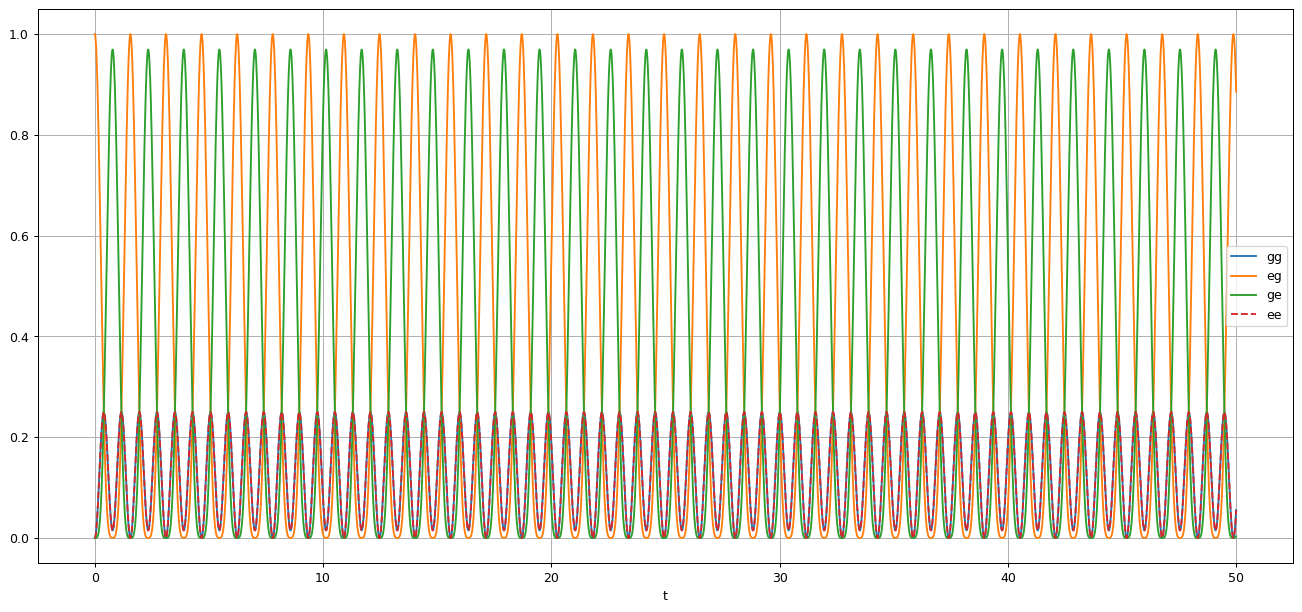

In [96]:
fig,ax = plt.subplots(figsize = (18,8), dpi = 90)
ax.plot(sol.t,np.abs(sol.y[0])**2, label = 'gg')
ax.plot(sol.t,np.abs(sol.y[1])**2, label = 'eg')
ax.plot(sol.t,np.abs(sol.y[2])**2, label = 'ge')
ax.plot(sol.t,np.abs(sol.y[3])**2, '--', label = 'ee')
# ax.plot(sol.t,np.abs(sol.y[1])**2 - np.abs(sol.y[2])**2, label = 'Sz')
ax.set_xlabel('t')
ax.legend()
ax.grid()